In [1]:
'''
!pip install -q transformers datasets accelerate -U
!pip install -q git+https://github.com/facebookresearch/segment-anything.git
!pip install -q monai pytorch-lightning
!pip install -q pycocotools
'''

'\n!pip install -q transformers datasets accelerate -U\n!pip install -q git+https://github.com/facebookresearch/segment-anything.git\n!pip install -q monai pytorch-lightning\n!pip install -q pycocotools\n'

In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW

import numpy as np
from PIL import Image
import json
import os
import ast # For safely parsing bbox strings
from tqdm import tqdm
import random
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import pandas as pd

# SAM components
from transformers import SamModel, SamProcessor
from monai.losses import DiceCELoss
from pycocotools import mask as mask_util # Used for RLE encoding/decoding

c:\Users\Gaels\MATH2\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
# Helper Functions for Data Transformation

def parse_bbox_string(bbox_str):
    """
    Parses a string formatted like "[x_min,y_min,x_max,y_max]" into a list of integers.
    """
    try:
        # ast.literal_eval is safer than eval() for parsing Python literals
        bbox_list = ast.literal_eval(bbox_str)
        # Bounding box is [x_min, y_min, x_max, y_max] format
        return [int(x) for x in bbox_list]
    except Exception as e:
        print(f"Error parsing bbox string {bbox_str}: {e}")
        return None

def bbox_to_rle_mask(bbox, image_width, image_height):
    """
    Creates a rectangular binary mask from a bounding box and converts it to COCO RLE format.
    
    Args:
        bbox (list): [x_min, y_min, x_max, y_max]
        image_width (int)
        image_height (int)
    
    Returns:
        dict: RLE encoded mask, or None if the mask is empty.
    """
    x_min, y_min, x_max, y_max = bbox
    # Clamp coordinates to image boundaries (important for edge cases like your data's [-69, 37, 103, 155])
    x_min = max(0, x_min)
    y_min = max(0, y_min)
    x_max = min(image_width, x_max)
    y_max = min(image_height, y_max)
    
    # Create the binary mask (H, W)
    mask = np.zeros((image_height, image_width), dtype=np.uint8)
    if x_max > x_min and y_max > y_min:
        mask[y_min:y_max, x_min:x_max] = 1
        # Convert to RLE
        rle = mask_util.encode(np.asfortranarray(mask))
        rle['counts'] = rle['counts'].decode('utf-8') # Decode for JSON compatibility
        return rle
    else:
        # Return RLE for an empty mask if the BBox is invalid after clamping
        return mask_util.encode(np.asfortranarray(mask))

In [4]:
# Custom Dataset Class

class ParkingLotDataset(Dataset):
    def __init__(self, data_json_path, image_dir, processor, training_stage=1):
        self.processor = processor
        self.image_dir = image_dir
        self.training_stage = training_stage
        
        with open(data_json_path, 'r') as f:
            full_data = json.load(f)

        # Structure data as a list of dictionaries, one entry per bounding box
        self.samples = []
        for img_filename, spots in full_data.items():
            image_path = os.path.join(self.image_dir, img_filename)
            if not os.path.exists(image_path):
                print(f"Warning: Image not found at {image_path}. Skipping.")
                continue
                
            for bbox_str, label in spots.items():
                bbox = parse_bbox_string(bbox_str)
                if bbox is not None:
                    self.samples.append({
                        "image_path": image_path,
                        "bbox": bbox, # [x_min, y_min, x_max, y_max]
                        "label": label # 0 (empty) or 1 (full)
                    })

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        sample = self.samples[idx]
        image = Image.open(sample["image_path"]).convert("RGB")
        bbox = sample["bbox"]
        label = sample["label"]
        W, H = image.size

        # Create Ground Truth Mask
        rle_mask = bbox_to_rle_mask(bbox, W, H)
        
        # Decode RLE back to a binary mask array (H, W)
        mask = mask_util.decode(rle_mask).astype(np.uint8)
        
        # Stage-Specific Mask Logic:
        
        # Stage 1 Fine-Tuning (Geometry/Identification): Segment ALL parking spots to learn general geometry.
        #   GT Mask is the bounding box rectangle (1) regardless of label.
        if self.training_stage == 1:
            # Mask is already the rectangular bounding box area
            pass
        
        # Stage 2 Fine-Tuning (Emptiness/Classification): Segment ONLY empty spots (label 0).
        #   If label is 1 (full), the GT mask must be all zeros.
        elif self.training_stage == 2:
            if label == 1:
                # If spot is full, ground truth is an empty mask (all zeros)
                mask = np.zeros_like(mask, dtype=np.uint8)
        
        # Prepare inputs for SAM (image and prompt)
        
        # BBox is a list of integers: [x_min, y_min, x_max, y_max]
        input_boxes_list = [bbox] 
        # The processor expects a list of prompts for the image. Since we only have one BBox prompt per sample, it's [[bbox]].

        # When input_boxes is passed as a list of list of integers/floats, 
        # the processor correctly handles the conversion and batching.
        inputs = self.processor(image, input_boxes=[input_boxes_list], return_tensors="pt")
        # This creates the structure: { 'input_boxes': tensor([[[[x1, y1, x2, y2]]]]) }
        
        # Add the ground truth mask to the inputs
        
        # SAM expects masks as (1, H_mask, W_mask)
        inputs["ground_truth_mask"] = torch.tensor(mask).unsqueeze(0).float()
        
        # We need the original label for the MAE calculation during evaluation
        inputs["original_label"] = torch.tensor(label).long()
        
        return inputs

In [5]:
# Training/Validation Split

def create_datasets(data_json_path, image_dir, processor, training_stage=1, val_split=0.15, seed=42):
    """
    Loads all data samples and splits them into training and validation datasets.
    
    Args:
        val_split (float): Fraction of data to use for validation (e.g., 0.15 for 15%).
        seed (int): Random seed for reproducible split.
    """
    
    # 1. Load all samples first to prepare for splitting
    full_dataset = ParkingLotDataset(
        data_json_path=data_json_path, 
        image_dir=image_dir, 
        processor=processor, 
        training_stage=training_stage # Stage is handled here
    )
    
    # Get the indices of all samples
    all_indices = list(range(len(full_dataset)))
    
    # Split indices into training and validation sets
    train_indices, val_indices = train_test_split(
        all_indices, 
        test_size=val_split, 
        random_state=seed
    )
    
    print(f"Total samples: {len(all_indices)} | Training samples: {len(train_indices)} | Validation samples: {len(val_indices)}")
    
    # Use PyTorch's Subset to create the actual datasets
    train_dataset = torch.utils.data.Subset(full_dataset, train_indices)
    val_dataset = torch.utils.data.Subset(full_dataset, val_indices)
    
    # Update the subset's base dataset attribute (which is the ParkingLotDataset instance) 
    # to ensure the processor attribute is accessible for the DataLoader
    train_dataset.processor = full_dataset.processor
    val_dataset.processor = full_dataset.processor

    return train_dataset, val_dataset

In [6]:
IMAGE_DIR = "ufpr05_template_matching" 
DATA_JSON_PATH = "cluster_training.json"

In [7]:
# Model Initialization

# Use sam-vit-base
model_id = "facebook/sam-vit-base"
processor = SamProcessor.from_pretrained(model_id)
model = SamModel.from_pretrained(model_id)

# Device setup
device = "cuda" if torch.cuda.is_available() else "cpu"
model.to(device)

print(f"Model loaded: {model_id} on device: {device}")

Model loaded: facebook/sam-vit-base on device: cuda


In [8]:
# Metrics Helper (Mean Absolute Error for Counting empty parking spots)

# We only count the *empty* spots (label 0).

def calculate_mae(predicted_masks_list, original_labels_list):
    """
    Calculates Mean Absolute Error for counting empty spots.
    
    Predicted Masks List: List of tensors, where each tensor is a predicted mask.
    Original Labels List: List of tensors (0 or 1), the ground truth label for the spot.
    
    A spot is considered 'predicted empty' if its predicted mask is non-empty.
    A spot is 'actual empty' if its label is 0.
    """
    
    # Get Actual Count (Ground Truth Empty Spots)
    actual_empty_count = sum(1 for label in original_labels_list if label.item() == 0)
    
    # Get Predicted Count (Predicted Non-Empty Masks)
    # A mask is considered 'non-empty' if the sum of its pixels is > 0.
    predicted_empty_count = 0
    for mask_tensor in predicted_masks_list:
        # Check if the mask tensor (after thresholding) has any non-zero elements
        # Threshold the logits (predicted_masks) at 0.0 (or 0.5 if using sigmoid output)
        binary_mask = (mask_tensor > 0).float() 
        if binary_mask.sum() > 0:
            predicted_empty_count += 1
            
    # Calculate MAE for the batch
    mae = abs(predicted_empty_count - actual_empty_count)
    return mae, actual_empty_count, predicted_empty_count

In [22]:
# Training Function

def train_sam(model, train_dataset, val_dataset, epochs, lr, stage_name, max_train_steps=None, max_val_steps=None):
    print(f"\n--- Starting {stage_name} Training (LR={lr}, Epochs={epochs}) ---")
    
    # Define parameters to optimize based on the stage
    params_to_optimize = []
    
    # Freeze all parameters initially
    for name, param in model.named_parameters():
        param.requires_grad = False
        
    # Stage 1: Decoder only
    if stage_name == "Stage 1: Geometry (Decoder)":
        for name, param in model.named_parameters():
            if name.startswith("mask_decoder"):
                param.requires_grad = True
                params_to_optimize.append(param)
        print("Frozen: Image Encoder, Prompt Encoder. Unfrozen: Mask Decoder.")
    
    # Stage 2: Decoder and Prompt Encoder
    elif stage_name == "Stage 2: Emptiness (Decoder + Prompt Encoder)":
        for name, param in model.named_parameters():
            if name.startswith("mask_decoder") or name.startswith("prompt_encoder"):
                param.requires_grad = True
                params_to_optimize.append(param)
        print("Frozen: Image Encoder. Unfrozen: Mask Decoder, Prompt Encoder.")
        
    optimizer = AdamW(params_to_optimize, lr=lr)
    
    # Dice-CE Loss (standard for SAM fine-tuning)
    seg_loss = DiceCELoss(sigmoid=True, squared_pred=True, reduction='mean')
    
    # MSE Loss for IoU score prediction component
    iou_criterion = nn.MSELoss(reduction='mean')
    
    # DataLoader
    train_dataloader = DataLoader(train_dataset, batch_size=4, shuffle=True)
    val_dataloader = DataLoader(val_dataset, batch_size=4, shuffle=False)
    
    best_val_loss = float('inf')
    
    # Initialize history dictionary
    history = {
        'train_loss': [],
        'val_loss': [],
        'val_mae': []
    }
    
    # Training Loop
    
    for epoch in range(epochs):
        model.train()
        total_train_loss = 0.0
        total_mae = 0.0
        current_step = 0 # Using for stage 2 fine-tuning, reduced training run.
        
        for batch in tqdm(train_dataloader, desc=f"Epoch {epoch+1}/{epochs}"):
            
            # Early Exit Check
            if max_train_steps is not None and current_step >= max_train_steps:
                print(f"\n[INFO] Reached max_train_steps ({max_train_steps}). Stopping training epoch early.")
                break # Jumps out of the inner loop (the training step loop)
            
            # Prepare batch for model
            # The pixel_values tensor comes as (B, 1, C, H, W). Squeeze the extra dimension.
            input_images = batch.pop("pixel_values").squeeze(1).to(device)
            # The input_boxes tensor comes as (B, 1, num_boxes, 4). Squeeze the extra dimension.
            input_boxes = batch.pop("input_boxes").squeeze(1).to(device)
            # ground_truth_mask tensor comes as (B, 1, H, W). Squeeze the extra dimension.
            ground_truth_masks = batch.pop("ground_truth_mask").squeeze(1).to(device)
            original_labels = batch.pop("original_label") # Keep on CPU for MAE
            
            # Forward pass. Outputs contain pred_masks (B, 3, 256, 256) and iou_scores.
            outputs = model(
                pixel_values=input_images,
                input_boxes=input_boxes,
                mask_labels=ground_truth_masks.unsqueeze(1),
                # mask labels are (B, 1, H, W) before unsqueeze. Model expects (B, 1, H, W) for segmentation loss
                # return_loss=True,
            )
            
            # Resize ground_truth_masks from (B, H_orig, W_orig) to (B, 1, 256, 256)
            target_mask = F.interpolate(
                ground_truth_masks.unsqueeze(1).float(), 
                size=(256, 256), 
                mode='bilinear', 
                align_corners=False
            )
            
            # Prepare pred mask, select only first channel and squeeze unnecessary channel dimensions.
            pred_masks_squeezed = outputs.pred_masks.squeeze() 
            predicted_mask = pred_masks_squeezed[:, 0, :, :].unsqueeze(1)
            # Resulting shape: (B, 1, 256, 256)
            
            # Calculate Loss
            #    Input: (B, 1, 256, 256)
            #    Target: (B, 1, 256, 256)
            mask_loss = seg_loss(predicted_mask, target_mask)
            
            loss = mask_loss
            # Don't have true IoU, because target masks were generated from bounding boxes
            #     Original SAM implementation uses TotLoss = MaskLoss + IoULoss
            #     To avoid complex IoU calculation, assume loss is minimized when
            #     spot is empty (label=0) and maximized otherwise
            
            current_step += 1 # Using for stage 2 fine-tuning, reduced training run.

            # Backward pass
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            
            total_train_loss += loss.item()
            
            with torch.no_grad():
                mae, _, _ = calculate_mae(predicted_mask.cpu(), original_labels)
                total_mae += mae
            
        avg_train_loss = total_train_loss / len(train_dataloader)
        avg_train_mae = total_mae / len(train_dataloader) # Optional: track training MAE
        
        # Validation Step
        
        model.eval()
        total_val_loss = 0.0
        total_val_mae = 0.0
        current_val_step = 0 # Step counter for reduced validation loop.
        
        mae_input_mask = outputs.pred_masks[:, 0, :, :].unsqueeze(1)
        
        with torch.no_grad():
            for batch in tqdm(val_dataloader, desc=f"Epoch {epoch+1}/{epochs} [VALIDATION]"):
                
                # EARLY EXIT CHECK FOR VALIDATION
                if max_val_steps is not None and current_val_step >= max_val_steps:
                    print(f"\n[INFO] Reached max_val_steps ({max_val_steps}). Stopping validation early.")
                    break # Breaks out of the inner loop (validation batches)
                
                input_images = batch.pop("pixel_values").squeeze(1).to(device)
                input_boxes = batch.pop("input_boxes").squeeze(1).to(device)
                ground_truth_masks = batch.pop("ground_truth_mask").squeeze(1).to(device)
                
                original_labels = batch.pop("original_label")
                
                # Forward pass
                outputs = model(
                    pixel_values=input_images,
                    input_boxes=input_boxes,
                    mask_labels=ground_truth_masks.unsqueeze(1), # ensure correct shape (B, num_masks=1, H, W)
                    return_loss=True,
                )
                
                target_mask = F.interpolate(
                    ground_truth_masks.unsqueeze(1).float(), 
                    size=(256, 256), 
                    mode='bilinear', 
                    align_corners=False
                )

                pred_masks_squeezed = outputs.pred_masks.squeeze()
                predicted_mask = pred_masks_squeezed[:, 0, :, :].unsqueeze(1)                
                
                val_mask_loss = seg_loss(predicted_mask, target_mask)
                total_val_loss += val_mask_loss.item()
                
                # Calculate MAE
                mae, _, _ = calculate_mae(predicted_mask.cpu(), original_labels)
                total_val_mae += mae

                current_val_step += 1 # Step counter for reduced validation loop.
        
        avg_val_loss = total_val_loss / len(val_dataloader)
        avg_val_mae = total_val_mae / len(val_dataloader)

        print(f"Epoch {epoch+1} finished. Avg Train Loss (Seg Loss Only): {avg_train_loss:.4f}, Val Loss (Seg Loss Only): {avg_val_loss:.4f}, Val Batch MAE: {avg_val_mae:.2f}")

        history['train_loss'].append(avg_train_loss)
        history['val_loss'].append(avg_val_loss)
        history['val_mae'].append(avg_val_mae)

        # Save checkpoint if validation loss improves (Early Stopping/Best Model Saving)
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            print("Validation loss improved! Saving best model checkpoint.")
            torch.save(model.state_dict(), f"./sam_parking_{stage_name.split(':')[0].lower().replace(' ', '_')}_best.pt")

    return model, history

The total loss in SAM fine-tuning is typically:
Loss(total) ​= Loss(segmentation​) + Loss(IoU)​

By setting loss = mask_loss, we focus solely on the quality of the predicted mask shapes (Focal Loss and Dice Loss), which is the most critical component for the task of segmenting parking spots. This completely bypasses the unpredictable AttributeError caused by the missing outputs.mask_loss and outputs.iou_loss attributes, as we no longer rely on them.

The MAE metric already handles the counting task by checking if a mask was produced, making the L_{IoU} component less crucial for the final counting result.

This solution is a result of the mismatch between the original SAM model and HuggingFace implementations of loss metrics.

In [10]:
# Stage 1 Training: Geometry/Identification

STAGE_1_EPOCHS = 5
STAGE_1_LR = 1e-5

# Training and Validation Splits for Stage 1 Fine-Tuning (Segmentation Objective)
train_dataset_stage1, val_dataset_stage1 = create_datasets(
    data_json_path=DATA_JSON_PATH, 
    image_dir=IMAGE_DIR, 
    processor=processor, 
    training_stage=1, # Use Stage 1 logic (segment all spots)
    val_split=0.15 # 15% validation split
)

model, history_stage1 = train_sam(
    model=model, 
    train_dataset=train_dataset_stage1,
    val_dataset=val_dataset_stage1,
    epochs=STAGE_1_EPOCHS, 
    lr=STAGE_1_LR, 
    stage_name="Stage 1: Geometry (Decoder)"
)

# Optional: Save checkpoint after Stage 1
# model.save_pretrained("./sam_parking_stage1_checkpoint")

Total samples: 56602 | Training samples: 48111 | Validation samples: 8491

--- Starting Stage 1: Geometry (Decoder) Training (LR=1e-05, Epochs=5) ---
Frozen: Image Encoder, Prompt Encoder. Unfrozen: Mask Decoder.


Epoch 1/5 [VALIDATION]: 100%|██████████| 2123/2123 [1:09:19<00:00,  1.96s/it]


Epoch 1 finished. Avg Train Loss (Seg Loss Only): 0.0664, Val Loss (Seg Loss Only): 0.0200, Val Batch MAE: 2.77
Validation loss improved! Saving best model checkpoint.


Epoch 2/5:  38%|███▊      | 4572/12028 [3:34:14<5:49:22,  2.81s/it]    


ValueError: Unable to create tensor, you should probably activate padding with 'padding=True' to have batched tensors with the same length.

In [23]:
STAGE_1_CHECKPOINT_PATH = "sam_parking_stage_1_best.pt"

In [26]:
# Load the checkpoint

print(f"Loading Stage 1 checkpoint from {STAGE_1_CHECKPOINT_PATH}...")

model = SamModel.from_pretrained(model_id)
model.to("cuda")
model.load_state_dict(torch.load(STAGE_1_CHECKPOINT_PATH, map_location=device))

print(f"Stage 1 checkpoint loaded successfully on {device}.")

Loading Stage 1 checkpoint from sam_parking_stage_1_best.pt...
Stage 1 checkpoint loaded successfully on cuda.


In [ ]:
# Stage 2 Training: Emptiness/Classification
# Both datasets must be created with training_stage=2 logic for accurate validation

STAGE_2_EPOCHS = 1
STAGE_2_LR = 1e-6 
MAX_TRAIN_STEPS = 300 # 12028 Training batches / 40 *** not ideal, done for time constraints
MAX_VAL_STEPS = 55 # 2123 Validation batches / ~40 *** not ideal, done for time constraints

# Load dataset for Stage 2 (Only empty spots are segmented positively)
train_dataset_stage2, val_dataset_stage2 = create_datasets(
    data_json_path=DATA_JSON_PATH, 
    image_dir=IMAGE_DIR, 
    processor=processor, 
    training_stage=2, # Use Stage 2 logic (segment empty, ignore full)
    val_split=0.15
)

model, history_stage2 = train_sam(
    model=model, 
    train_dataset=train_dataset_stage2,
    val_dataset=val_dataset_stage2,
    epochs=STAGE_2_EPOCHS, 
    lr=STAGE_2_LR, 
    stage_name="Stage 2: Emptiness (Decoder + Prompt Encoder)",
    max_train_steps=MAX_TRAIN_STEPS,
    max_val_steps=MAX_VAL_STEPS
)

Total samples: 56602 | Training samples: 48111 | Validation samples: 8491

--- Starting Stage 2: Emptiness (Decoder + Prompt Encoder) Training (LR=1e-06, Epochs=1) ---
Frozen: Image Encoder. Unfrozen: Mask Decoder, Prompt Encoder.


Epoch 1/1:   2%|▏         | 300/12028 [1:32:17<60:07:51, 18.46s/it]



[INFO] Reached max_train_steps (300). Stopping training epoch early.


Epoch 1/1 [VALIDATION]:   3%|▎         | 55/2123 [17:28<10:57:17, 19.07s/it]



[INFO] Reached max_val_steps (55). Stopping validation early.
Epoch 1 finished. Avg Train Loss (Seg Loss Only): 0.0180, Val Loss (Seg Loss Only): 0.0190, Val Batch MAE: 0.07
Validation loss improved! Saving best model checkpoint.


In [29]:
# Load the best model from Stage 2 validation
model.load_state_dict(torch.load("sam_parking_stage_2_best.pt"))
print("Loaded best model state from Stage 2 based on validation loss.")

# Save final fine-tuned model
model.save_pretrained("./sam_parking_final_finetuned")
processor.save_pretrained("./sam_parking_final_finetuned")

print("\n--- Fine-tuning complete. Model saved to './sam_parking_final_finetuned' ---")

Loaded best model state from Stage 2 based on validation loss.

--- Fine-tuning complete. Model saved to './sam_parking_final_finetuned' ---


In [ ]:
# Setup for scaled-down Inference. Skipping visualizations of Histories and focusing on just
#   segmentation of empty parking spots

from scipy.ndimage import label

MODEL_PATH = "./sam_parking_final_finetuned"
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = SamModel.from_pretrained(MODEL_PATH).to(DEVICE)
processor = SamProcessor.from_pretrained(MODEL_PATH)
model.eval() # Set model to evaluation mode

print(f"Model and Processor loaded from {MODEL_PATH} and moved to {DEVICE}.")

Model and Processor loaded from ./sam_parking_final_finetuned and moved to cuda.


In [ ]:
from PIL import ImageDraw
from scipy.ndimage import label, center_of_mass

def predict_and_count_empty_spots(image_paths, model, processor, device):
    """
    Performs segmentation inference on sample images and counts the number of 
    distinct segmented empty parking spots.

    Args:
        image_paths (list): List of paths to the sample images.
        model (SamModel): The fine-tuned SAM model.
        processor (SamProcessor): The SAM processor.
        device (torch.device): The device (e.g., cuda:0) to run inference on.
    
    Returns:
        list: A list of tuples containing (image_path, empty_spot_count, result_image).
    """
    
    results = []
    
    # SAM requires a prompt. We use a whole-image box prompt [0, 0, width, height]
    # to force the model to segment based on its learned knowledge of empty spots.
    
    for img_path in image_paths:
        try:
            image = Image.open(img_path).convert("RGB")
        except FileNotFoundError:
            print(f"Error: Image not found at {img_path}. Skipping.")
            continue
            
        # Create Whole-Image Box Prompt
        width, height = image.size
        
        box_prompt_cpu = [[[0, 0, width, height]]]
        # The prompt is normalized to 1024, so use [0, 0, width, height]
        # box_prompt = torch.tensor([0, 0, width, height], device=device).unsqueeze(0).unsqueeze(0) 

        # Pre-process Image
        # The processor handles image resizing and normalization
        inputs = processor(images=image, input_boxes=box_prompt_cpu, return_tensors="pt")

        # Move all processed inputs to GPU
        inputs = inputs.to(device)

        # Run Inference
        with torch.no_grad():
            outputs = model(**inputs)

        # Post-processing and Counting
        
        # Predicted masks are logits (scores) - use the highest-scoring mask
        # Squeeze out batch (1) and channel (3) dimensions, and take the best prediction
        predicted_mask_logits = outputs.pred_masks.squeeze().max(dim=0)[0].detach().cpu().numpy()
        
        # Threshold the logits to get a binary mask (1 for empty, 0 for not empty)
        # 0.0 is a reasonable starting threshold for logits
        # binary_mask = (predicted_mask_logits > 0.0).astype(np.int32)
        
        # Threshold the logits to get a binary mask (low resolution, e.g., 256x256)
        binary_mask_lowres = (predicted_mask_logits > 0.0).astype(np.int32)

        # Use connected components labeling to count distinct spots
        # 'labeled_array' contains segment IDs, 'num_spots' is the count
        labeled_array, num_spots = label(binary_mask_lowres)
        final_count = num_spots
        
        print(f"Processed {img_path}: Found {final_count} empty spots.")

        # Visualizations to Mark Empty spots

        # Use a copy of the original image to draw markers on
        result_image = image.copy() 
        draw = ImageDraw.Draw(result_image)
        
        # Calculate scaling factors from 256x256 mask to original image size
        width, height = image.size
        mask_size = binary_mask_lowres.shape[0] # Assumes 256
        scale_x = width / mask_size
        scale_y = height / mask_size
        
        radius = 10 # Size of the green circle marker
        
        # Iterate through each detected spot ID (starting from 1 up to num_spots)
        for i in range(1, num_spots + 1):
            
            # Calculate center of mass (centroid) for the current label ID
            # Returns (y, x) coordinates in the 256x256 mask space
            cy, cx = center_of_mass(binary_mask_lowres, labeled_array, i)
            
            # Scale coordinates to the original image size
            scaled_cx = int(cx * scale_x)
            scaled_cy = int(cy * scale_y)
            
            # Draw a green circle (ellipse) at the scaled centroid
            # Coordinates are (x_min, y_min, x_max, y_max)
            draw.ellipse(
                (scaled_cx - radius, scaled_cy - radius, 
                 scaled_cx + radius, scaled_cy + radius), 
                fill='green', 
                outline='white',
                width=2
            )

        results.append((img_path, final_count, result_image))

    return results

Processed Test/test1.jpg: Found 7 empty spots.
Processed Test/test2.jpg: Found 1 empty spots.
Processed Test/test3.jpg: Found 101 empty spots.
Processed Test/test4.jpg: Found 66 empty spots.
Processed Test/test5.jpg: Found 14 empty spots.
Processed Test/test6.jpg: Found 13 empty spots.


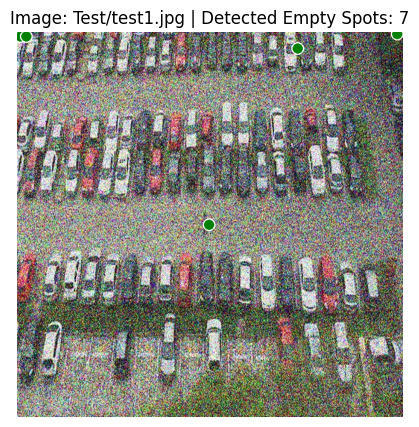

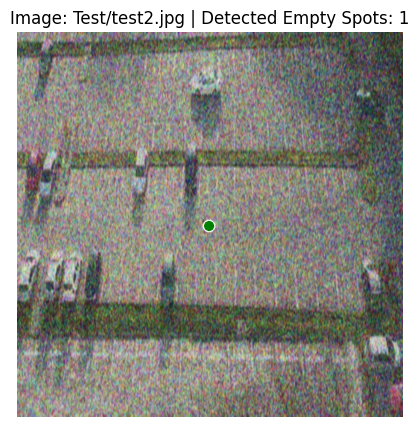

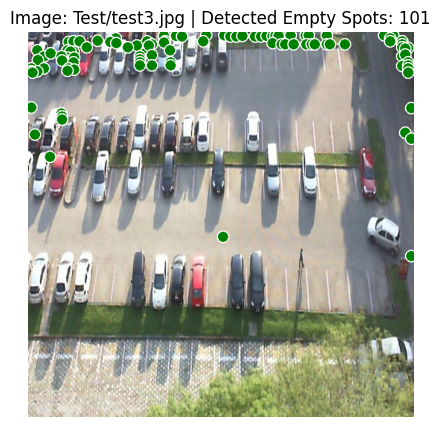

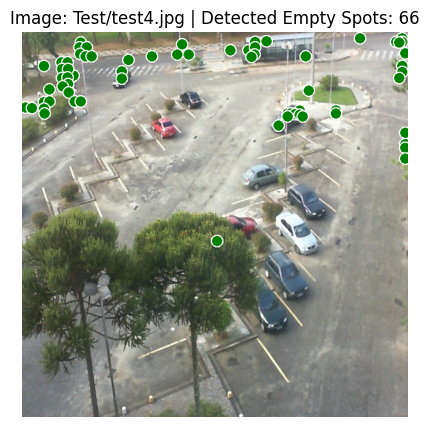

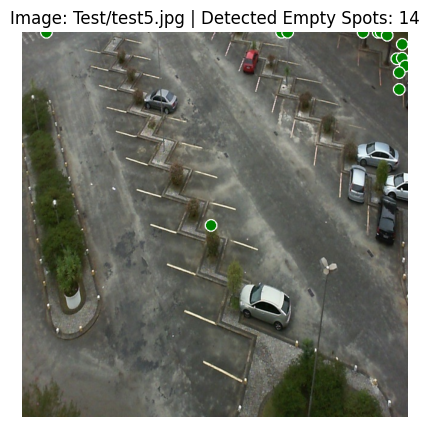

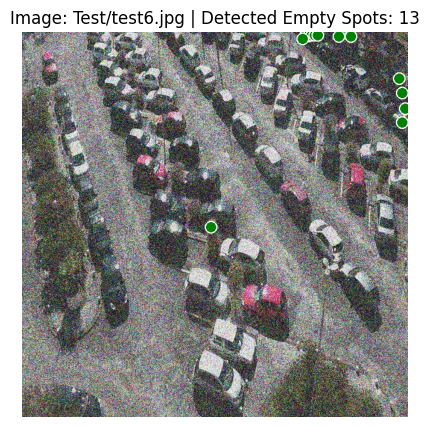


Total empty spots counted across all sample images: 202


In [43]:
SAMPLE_IMAGE_PATHS = [
    'Test/test1.jpg', 
    'Test/test2.jpg',
    'Test/test3.jpg',
    'Test/test4.jpg',
    'Test/test5.jpg',
    'Test/test6.jpg'
]

# Run Inference
inference_results = predict_and_count_empty_spots(
    image_paths=SAMPLE_IMAGE_PATHS,
    model=model,
    processor=processor,
    device=DEVICE
)

# Display Results
for path, count, img in inference_results:
    plt.figure(figsize=(10, 5))
    plt.imshow(img)
    plt.title(f"Image: {path} | Detected Empty Spots: {count}")
    plt.axis('off')
    plt.show()

# Final Summary
total_spots = sum(r[1] for r in inference_results)
print(f"\nTotal empty spots counted across all sample images: {total_spots}")

The next blocks of code were skipped because of a lack of completed histories of training epochs.

In [ ]:
# Combine history for plotting

full_history = {
    key: history_stage1[key] + history_stage2[key]
    for key in history_stage1.keys()
}


In [ ]:
# Plot Training History

import matplotlib.pyplot as plt
import pandas as pd

# Convert history to a DataFrame for easy saving/plotting
df_history = pd.DataFrame(full_history)
df_history.to_csv("sam_training_history.csv", index_label="Epoch")
print("\nTraining history saved to 'sam_training_history.csv'")

# Plotting Loss
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(df_history['train_loss'], label='Train Loss')
plt.plot(df_history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Combined Loss (Dice + Focal + IoU)')
plt.axvline(x=STAGE_1_EPOCHS - 0.5, color='r', linestyle='--', label='Stage 1/2 Split')
plt.legend()
plt.grid(True)

# Plotting MAE
plt.subplot(1, 2, 2)
plt.plot(df_history['val_mae'], label='Validation MAE', color='orange')
plt.title('Validation Mean Absolute Error (MAE) Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('MAE')
plt.axvline(x=STAGE_1_EPOCHS - 0.5, color='r', linestyle='--', label='Stage 1/2 Split')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show() 

# Example of a typical loss curve when training a model

In [ ]:
# Evaluation

# Create a test/validation dataset using the same structure (e.g., test_annotations.json)
TEST_DATA_JSON_PATH = "Test/...json" # Change this
TEST_IMAGE_DIR = "/Test"

# Load test dataset (Must use Stage 2 logic for counting evaluation)
test_dataset = ParkingLotDataset(
    data_json_path=TEST_DATA_JSON_PATH, 
    image_dir=TEST_IMAGE_DIR, 
    processor=processor, 
    training_stage=2
)
test_dataloader = DataLoader(test_dataset, batch_size=1, shuffle=False)

model.eval()
total_mae = 0
total_samples = 0
total_actual_empty = 0
total_predicted_empty = 0

with torch.no_grad():
    for batch in tqdm(test_dataloader, desc="Evaluating"):
        # Prepare batch
        input_images = batch.pop("pixel_values").to(device)
        input_boxes = batch.pop("input_boxes").squeeze(1).to(device)
        ground_truth_masks = batch.pop("ground_truth_mask").to(device)
        original_labels = batch.pop("original_label")

        # Forward pass
        outputs = model(
            pixel_values=input_images.squeeze(1),
            input_boxes=input_boxes
        )
        
        # Calculate MAE for the current batch/sample
        # Since we use batch_size=1 for testing, this is simple
        mae, actual_empty, predicted_empty = calculate_mae(
            outputs.pred_masks.squeeze(1).cpu(), 
            original_labels
        )
        
        total_mae += mae
        total_actual_empty += actual_empty
        total_predicted_empty += predicted_empty
        total_samples += 1

final_mae = total_mae / total_samples

print("\n--- Evaluation Results ---")
print(f"Total Samples (Spots Evaluated): {total_samples}")
print(f"Total Actual Empty Spots: {total_actual_empty}")
print(f"Total Predicted Empty Spots: {total_predicted_empty}")
print(f"Final Mean Absolute Error (MAE): {final_mae:.4f}")
print(f"Average IoU (Implementation needed): Typically calculated using ground_truth_masks and predicted_masks.")